In [1]:
SEED = 42
import numpy as np
import torch
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
from pathlib import Path
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR   = Path("../data/processed/FD001")
MODELS_DIR = Path("../data/processed/FD001/checkpoints_cgan")
SYNTH_DIR  = Path("../data/synthetic/GAN")
SYNTH_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(MODELS_DIR / "model_config.json") as f:
    cfg = json.load(f)

SEQ_LEN     = cfg["seq_len"]
INPUT_DIM   = cfg["input_dim"]
HIDDEN_DIM  = cfg["hidden_dim"]
LATENT_DIM  = cfg["latent_dim"]
NUM_CLASSES = cfg["num_classes"]
EMBED_DIM   = cfg["embed_dim"]

X      = np.load(DATA_DIR / "X_train.npy")
labels = np.load(DATA_DIR / "labels_train.npy")

CLASS_NAMES  = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]

print(f"X      : {X.shape}")
print(f"labels : {labels.shape}")
print(f"Class counts: {Counter(labels.tolist())}")
print(f"Device : {DEVICE}")
print(f"Config : {cfg}")


X      : (17731, 30, 16)
labels : (17731,)
Class counts: Counter({0: 7633, 1: 4998, 2: 4000, 3: 1100})
Device : cpu
Config : {'seq_len': 30, 'input_dim': 16, 'hidden_dim': 128, 'latent_dim': 64, 'num_classes': 4, 'embed_dim': 16, 'model_type': 'cgan'}


In [ ]:
# BUG-007: Safe checkpoint loading helper
def _safe_load(model, ckpt_path):
    """Load state dict with key validation."""
    ckpt_path = Path(ckpt_path)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    expected = set(model.state_dict().keys())
    actual = set(ckpt.keys())
    if expected != actual:
        raise ValueError(
            f"Checkpoint key mismatch for {ckpt_path.name}:\n"
            f"  Expected keys : {sorted(expected)}\n"
            f"  Checkpoint keys: {sorted(actual)}"
        )
    model.load_state_dict(ckpt, strict=True)
    print(f"Loaded: {ckpt_path.name}")


In [ ]:
# BUG-002: Use CGAN architecture instead of TimeGAN
import torch.nn as nn


class CGANGenerator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, seq_len, input_dim, num_classes, embed_dim):
        super().__init__()
        self.seq_len = seq_len
        self.class_embed = nn.Embedding(num_classes, embed_dim)
        self.fc_in = nn.Linear(latent_dim + embed_dim, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, input_dim)

    def forward(self, z, c):
        emb = self.class_embed(c)           # (B, embed_dim)
        x = torch.cat([z, emb], dim=-1)     # (B, latent+embed)
        x = torch.relu(self.fc_in(x))       # (B, hidden)
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)  # (B, T, hidden)
        x, _ = self.gru(x)                  # (B, T, hidden)
        return torch.sigmoid(self.fc_out(x))  # (B, T, input_dim)


class CGANDiscriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, embed_dim):
        super().__init__()
        self.class_embed = nn.Embedding(num_classes, embed_dim)
        self.gru = nn.GRU(input_dim + embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, x, c):
        emb = self.class_embed(c).unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, emb], dim=-1)
        out, _ = self.gru(x)
        return self.fc_out(out[:, -1, :])


G_net = CGANGenerator(LATENT_DIM, HIDDEN_DIM, SEQ_LEN, INPUT_DIM, NUM_CLASSES, EMBED_DIM).to(DEVICE)
D_net = CGANDiscriminator(INPUT_DIM, HIDDEN_DIM, NUM_CLASSES, EMBED_DIM).to(DEVICE)

_safe_load(G_net, MODELS_DIR / "generator.pt")
_safe_load(D_net, MODELS_DIR / "discriminator.pt")
G_net.eval()
D_net.eval()
print("CGAN checkpoints loaded.")


In [ ]:
# BUG-002: CGAN-based generation function
def generate_samples(generator, n_samples, class_id, device):
    """Generate n_samples synthetic windows for class_id using CGAN."""
    all_samples = []
    batch_size = 128
    with torch.no_grad():
        generated = 0
        while generated < n_samples:
            bs = min(batch_size, n_samples - generated)
            z = torch.randn(bs, LATENT_DIM).to(device)
            c = torch.full((bs,), class_id, dtype=torch.long).to(device)
            x_hat = generator(z, c).cpu().numpy()  # (bs, T, D)
            all_samples.append(x_hat)
            generated += bs
    return np.concatenate(all_samples, axis=0)


In [4]:
real_counts  = Counter(labels.tolist())
target_count = max(real_counts.values())

print("Real class counts:")
for c, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {real_counts[c]}")

print(f"\nTarget count per class (balanced): {target_count}")

synth_needed = {}
for c in range(NUM_CLASSES):
    needed = max(0, target_count - real_counts[c])
    synth_needed[c] = needed
    print(f"  {CLASS_NAMES[c]}: generate {needed} synthetic samples")


Real class counts:
  C0 healthy: 7633
  C1 early: 4998
  C2 advanced: 4000
  C3 imminent: 1100

Target count per class (balanced): 7633
  C0 healthy: generate 0 synthetic samples
  C1 early: generate 2635 synthetic samples
  C2 advanced: generate 3633 synthetic samples
  C3 imminent: generate 6533 synthetic samples


In [ ]:
synth_X      = []
synth_labels = []

for c in range(NUM_CLASSES):
    n = synth_needed[c]
    if n == 0:
        print(f"C{c}: no generation needed, skipping.")
        continue

    print(f"Generating {n} samples for C{c} ({CLASS_NAMES[c]})...")
    samples = generate_samples(G_net, n, c, DEVICE)
    synth_X.append(samples)
    synth_labels.append(np.full(n, c, dtype=np.int64))
    print(f"  Done - shape: {samples.shape}")

synth_X      = np.concatenate(synth_X,      axis=0)
synth_labels = np.concatenate(synth_labels, axis=0)

print(f"\nTotal synthetic generated : {synth_X.shape}")
print(f"Synthetic label counts    : {Counter(synth_labels.tolist())}")


In [ ]:
# BUG-004: Rescale synthetic features to match real statistics
X_real_flat = X.reshape(-1, INPUT_DIM)
real_mean = X_real_flat.mean(axis=0)
real_std = X_real_flat.std(axis=0)
EPS = 1e-8


def rescale_to_real_stats(synth):
    """Rescale synthetic array (N,30,D) to match real feature statistics, clipped to [0,1]."""
    flat = synth.reshape(-1, INPUT_DIM)
    raw_mean = flat.mean(axis=0)
    raw_std = flat.std(axis=0)
    flat_rescaled = ((flat - raw_mean) / (raw_std + EPS)) * real_std + real_mean
    flat_rescaled = np.clip(flat_rescaled, 0.0, 1.0)
    return flat_rescaled.reshape(synth.shape).astype(np.float32)


synth_X_rescaled = rescale_to_real_stats(synth_X)
SYNTH_DIR.mkdir(parents=True, exist_ok=True)
np.save(SYNTH_DIR / "synth_X.npy", synth_X_rescaled)
np.save(SYNTH_DIR / "synth_labels.npy", synth_labels)
print(f"Saved synth_X.npy (rescaled): {synth_X_rescaled.shape}")
print(f"Saved synth_labels.npy: {synth_labels.shape}")


In [ ]:
X_balanced      = np.concatenate([X,      synth_X_rescaled],      axis=0)
labels_balanced = np.concatenate([labels, synth_labels], axis=0)

idx = np.random.permutation(len(X_balanced))
X_balanced      = X_balanced[idx]
labels_balanced = labels_balanced[idx]

print(f"Balanced dataset shape : {X_balanced.shape}")
print(f"Balanced class counts  : {Counter(labels_balanced.tolist())}")


In [ ]:
def generate_interpolated(generator, n_samples, alpha, c_from, c_to, device):
    """
    alpha=0.0 -> pure c_from, alpha=1.0 -> pure c_to
    Interpolates class embeddings in latent space.
    """
    all_samples = []
    batch_size  = 128

    with torch.no_grad():
        e_from   = generator.class_embed.weight[c_from]
        e_to     = generator.class_embed.weight[c_to]
        e_interp = (1 - alpha) * e_from + alpha * e_to   # (embed_dim,)

        generated = 0
        while generated < n_samples:
            bs  = min(batch_size, n_samples - generated)
            z   = torch.randn(bs, LATENT_DIM).to(device)
            emb = e_interp.unsqueeze(0).repeat(bs, 1)
            inp = torch.cat([z, emb], dim=-1)
            h   = torch.relu(generator.fc_in(inp))
            h_seq = h.unsqueeze(1).repeat(1, generator.seq_len, 1)
            out, _ = generator.gru(h_seq)
            X_hat  = torch.sigmoid(generator.fc_out(out)).cpu().numpy()
            all_samples.append(X_hat)
            generated += bs

    return np.concatenate(all_samples, axis=0)


N_INTERP     = 500
interp_C1_C2 = generate_interpolated(G_net, N_INTERP, 0.5, 1, 2, DEVICE)
interp_C2_C3 = generate_interpolated(G_net, N_INTERP, 0.5, 2, 3, DEVICE)

np.save(SYNTH_DIR / "interp_C1_C2.npy", interp_C1_C2)
np.save(SYNTH_DIR / "interp_C1_C2_labels.npy", np.ones(len(interp_C1_C2), dtype=np.int64))
np.save(SYNTH_DIR / "interp_C2_C3.npy", interp_C2_C3)
np.save(SYNTH_DIR / "interp_C2_C3_labels.npy", np.full(len(interp_C2_C3), 2, dtype=np.int64))
print(f"Saved interp_C1_C2.npy + labels: {interp_C1_C2.shape}")
print(f"Saved interp_C2_C3.npy + labels: {interp_C2_C3.shape}")


C:\Users\Ishaan Nandoskar\AppData\Local\Temp\ipykernel_460\2268829719.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[c, 1].legend(loc="upper right", fontsize=7)


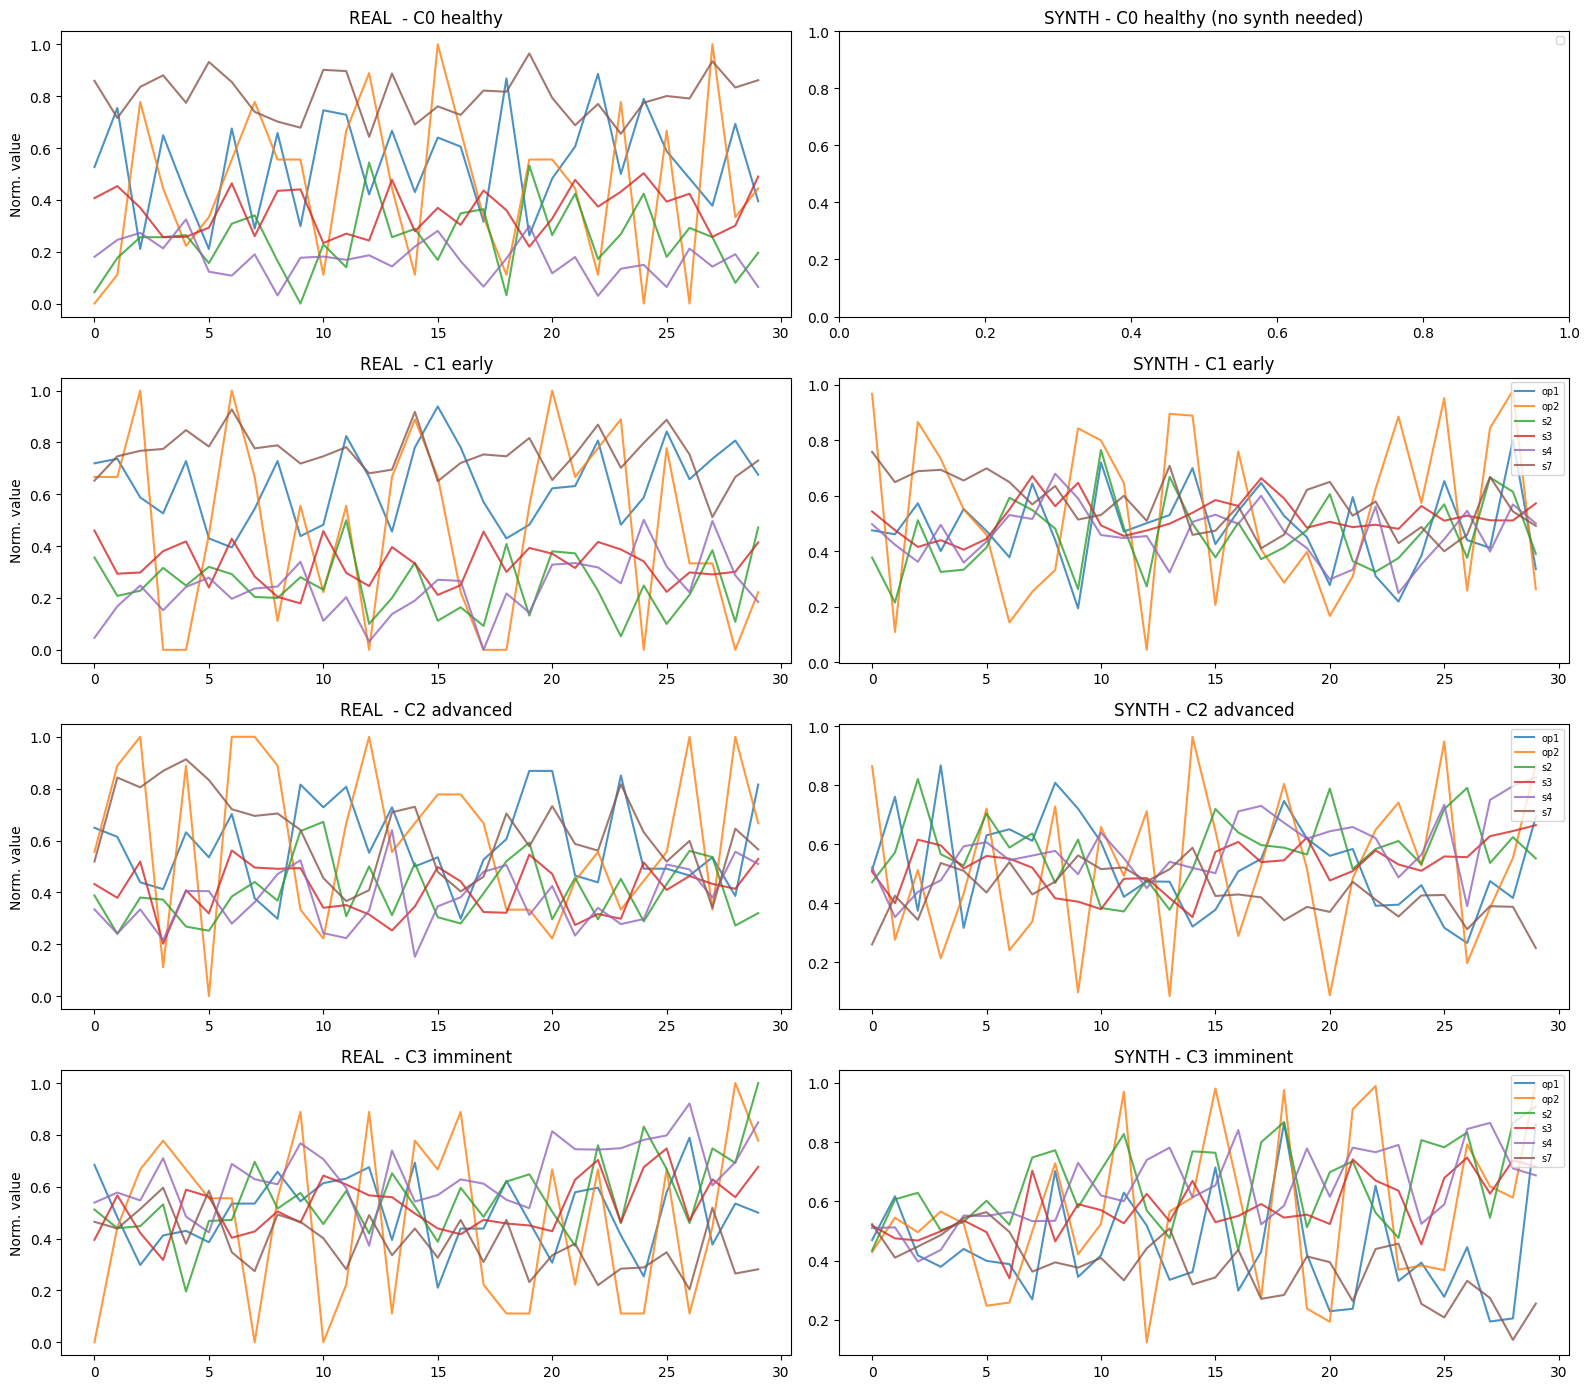

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for c in range(4):
    real_idx  = np.where(labels == c)[0]
    synth_idx = np.where(synth_labels == c)[0]

    real_seq  = X[real_idx[0]]       if len(real_idx)  > 0 else None
    synth_seq = synth_X[synth_idx[0]] if len(synth_idx) > 0 else None

    for i, col in enumerate(FEATURE_COLS[:6]):
        if real_seq  is not None: axes[c, 0].plot(real_seq[:, i],  label=col, alpha=0.8)
        if synth_seq is not None: axes[c, 1].plot(synth_seq[:, i], label=col, alpha=0.8)

    axes[c, 0].set_title(f"REAL  - {CLASS_NAMES[c]}" + ("" if real_seq  is not None else " (none)"))
    axes[c, 1].set_title(f"SYNTH - {CLASS_NAMES[c]}" + ("" if synth_seq is not None else " (no synth needed)"))
    axes[c, 0].set_ylabel("Norm. value")
    axes[c, 1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.savefig("../reports/figures/real_vs_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()


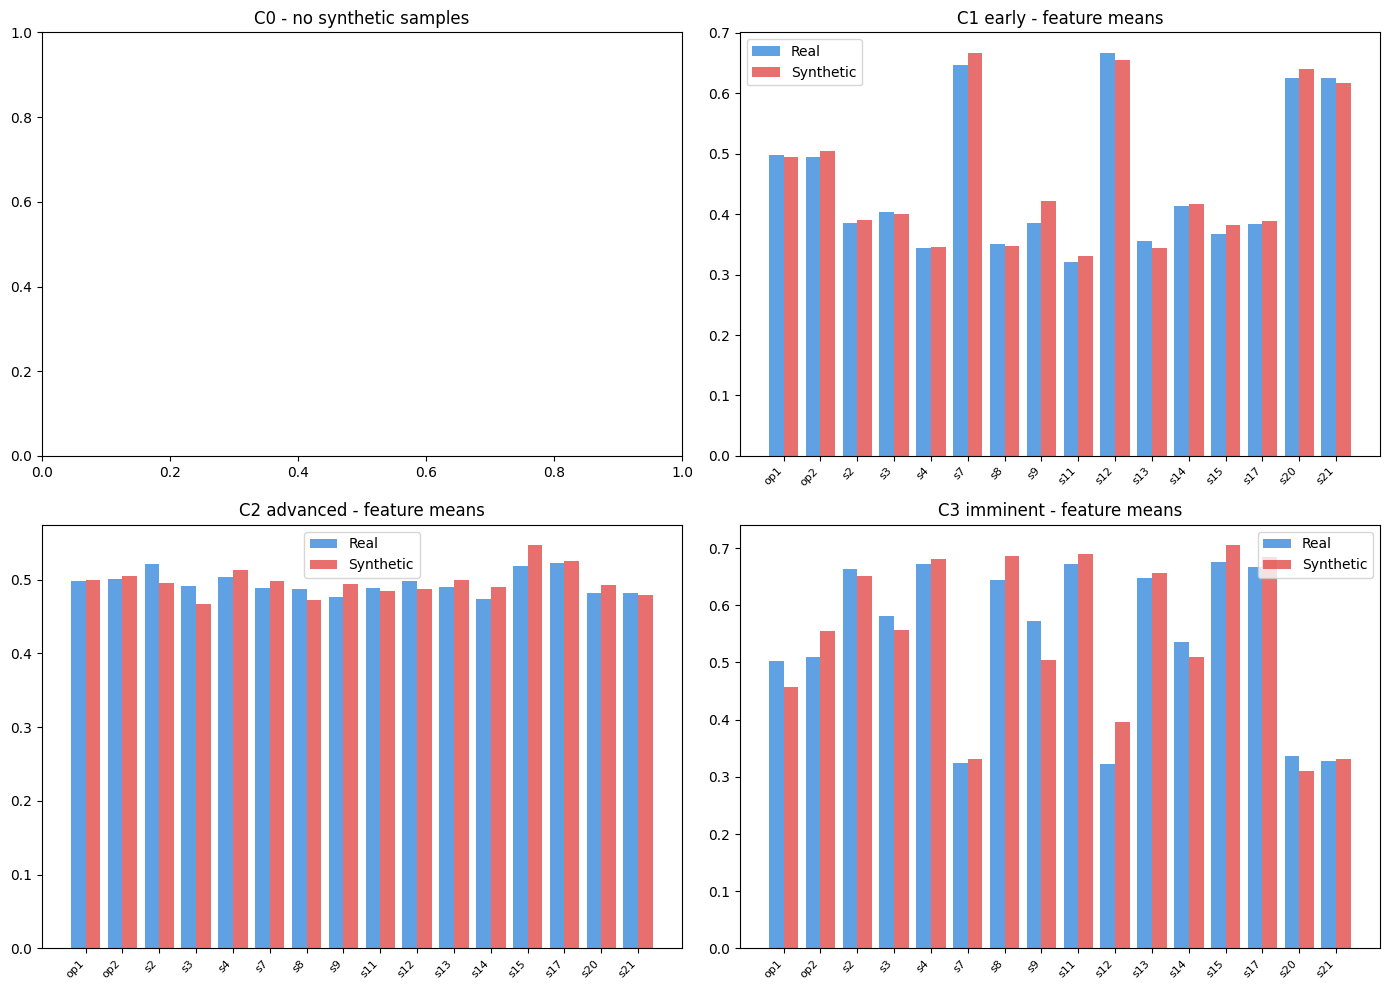

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for c, ax in enumerate(axes.flat):
    real_mean  = X[labels == c].mean(axis=(0, 1))
    synth_mask = synth_labels == c
    if synth_mask.sum() == 0:
        ax.set_title(f"C{c} - no synthetic samples")
        continue
    synth_mean = synth_X[synth_mask].mean(axis=(0, 1))

    x_pos = np.arange(len(FEATURE_COLS))
    ax.bar(x_pos - 0.2, real_mean,  width=0.4, label="Real",      color="#378ADD", alpha=0.8)
    ax.bar(x_pos + 0.2, synth_mean, width=0.4, label="Synthetic", color="#E24B4A", alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{CLASS_NAMES[c]} - feature means")
    ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/feature_means_real_vs_synth.png", dpi=150, bbox_inches="tight")
plt.show()
